# STAT5605 Project — Analysis Figures

This notebook generates all publication-quality figures for the project.  
**Data root:** `../data/`  |  **Output root:** `../outputs/figures/`

## 0. Imports & Global Style

In [69]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Output directory ──────────────────────────────────────────────────────────
FIG_OUT = '../outputs/figures'
os.makedirs(FIG_OUT, exist_ok=True)

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  '#FAFAF8',
    'axes.facecolor':    '#F3F0EB',
    'axes.edgecolor':    '#AAAAAA',
    'axes.labelcolor':   '#2A2A2A',
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'text.color':        '#1A1A1A',
    'grid.color':        '#DDDDDD',
    'grid.linewidth':    0.6,
})

BG        = '#FAFAF8'
PANEL_BG  = '#F3F0EB'

# Injury-class colour palette (A / B / C / K)
INJ_COLORS = {
    'K': "#421B53", #  — Fatal (Kill)
    'A': "#8D2519",   # — Suspected Serious
    'B': "#A85D1C",   # — Suspected Minor
    'C': "#E7C031",   # — Possible
}
INJ_LABELS = {
    'K': 'Fatal Injury',
    'A': 'Suspected Serious Injury',
    'B': 'Suspected Minor Injury',
    'C': 'Possible Injury',
}

# Precipitation category definitions (mm/hr)
PRECIP_BINS   = [0.0, 0.1, 2.5, 7.6, 25.0, np.inf]
PRECIP_LABELS = ['Dry', 'Light Rain', 'Moderate Rain', 'Heavy Rain', 'Extreme Rain']
PRECIP_THRESH = [
    r'$\leq 0.1$ mm/hr',
    r'$0.1 – 2.5$ mm/hr',
    r'$2.5 – 7.6$ mm/hr',
    r'$7.6 – 25$ mm/hr',
    r'$> 25$ mm/hr',
]

def save_fig(fig, name, dpi=220):
    """Save figure as both PNG and PDF."""
    for ext in ('png', 'pdf'):
        path = os.path.join(FIG_OUT, f'{name}.{ext}')
        fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved → {FIG_OUT}/{name}.[png|pdf]')

print('Setup complete.')

Setup complete.


## 1. Load Data

In [70]:
# ── Crash + weather data ──────────────────────────────────────────────────────
crash = pd.read_csv('../../data/clean_crash_data/crash_data_weather.csv')
crash['hourly_tp_mm'] = crash['hourly_tp_mm']*1000  # Convert from m to mm
print(f'crash_data_weather: {crash.shape[0]:,} rows × {crash.shape[1]} cols')
print(crash.dtypes)
crash.head(3)

crash_data_weather: 282,360 rows × 46 cols
Unnamed: 0                              int64
CrashId                                 int64
Latitude                              float64
Longitude                             float64
Town                                   object
Date Of Crash                          object
Day of the Week                       float64
Hour of the Day                       float64
Most Severe Injury                     object
Number Of Motor Vehicles              float64
Number Of Non-Motorist                float64
Route Class                           float64
First Harmful Event                   float64
Manner of Crash / Collision Impact    float64
Location of First Harmful Event       float64
Weather Condition                     float64
Light Condition                       float64
Road Surface Condition                float64
Crash Specific Location               float64
Type of Intersection                  float64
VehicleId                            

,Unnamed: 0,CrashId,Latitude,Longitude,Town,Date Of Crash,Day of the Week,Hour of the Day,Most Severe Injury,Number Of Motor Vehicles,...,Air Bag Status,Speeding Related,crash_dt,wx_lat,wx_lon,hourly_tp_mm,u10_ms,v10_ms,wind_speed_ms,wind_dir_deg
0,0,687,41.360649,-71.876469,Stonington,2015-01-03,7.0,11.0,C,2.0,...,NaN,NaN,2015-01-03 11:00:00,41.381,-71.82700,0.000862,-1.641248,-1.590963,2.285795,45.891293
1,1,690,41.368580,-72.719300,Guilford,2015-01-03,7.0,16.0,C,1.0,...,NaN,NaN,2015-01-03 16:00:00,41.381,-72.72747,0.000000,-3.654976,1.550164,3.970121,112.982982
2,2,692,41.449140,-73.402640,Brookfield,2015-01-05,2.0,17.0,C,2.0,...,NaN,NaN,2015-01-05 17:00:00,41.481,-73.42784,0.000000,4.651956,-1.888916,5.020826,292.099500


In [71]:
# ── Enhanced CT towns geodataframe (from data_cleaning.ipynb) ─────────────────
ct_towns = gpd.read_file('../../data/ct_towns_enhanced.gpkg')
print(f'ct_towns: {ct_towns.shape[0]} towns, columns: {ct_towns.columns.tolist()}')

ct_towns: 169 towns, columns: ['GEOID20', 'NAME20', 'DP03_0019E', 'DP03_0020E', 'DP03_0021E', 'DP03_0022E', 'DP03_0026E', 'DP03_0025E', 'DP03_0062E', 'DP05_0001E', 'road_mi_primary', 'road_mi_primary_undivided', 'road_mi_secondary', 'road_mi_secondary_undivided', 'road_mi_road_or_street', 'road_mi_total', 'area_sq_mi', 'pop_density_per_sq_mi', 'geometry']


## 2. Derived Columns
Categorise precipitation intensity and verify injury class values.

In [77]:
# ── Fix: extend left bin edge to capture exact zeros ─────────────────────────
PRECIP_BINS_FIXED = [-np.inf, 0.1, 2.5, 7.6, 25.0, np.inf]

crash['precip_cat'] = pd.cut(
    crash['hourly_tp_mm'],
    bins=PRECIP_BINS_FIXED,
    labels=PRECIP_LABELS,
    right=True,
)

# Verify — should now match injury count of 282,343
crash_v = crash[crash['Most Severe Injury'].isin(['A', 'B', 'C', 'K'])].copy()

print(f"Injury N  : {len(crash_v):,}")
print(f"Precip N  : {crash_v['precip_cat'].notna().sum():,}")
print()

prec_counts = crash_v['precip_cat'].value_counts().reindex(PRECIP_LABELS).fillna(0).astype(int)
prec_table = pd.DataFrame({
    'Category':   PRECIP_LABELS,
    'Threshold':  PRECIP_THRESH,
    'Count':      prec_counts.values,
    'Proportion': (prec_counts.values / prec_counts.sum() * 100).round(2),
})
print(prec_table.to_string(index=False))

# ── Injury table ──────────────────────────────────────────────────────────────
inj_order  = ['K', 'A', 'B', 'C']
inj_counts = crash_v['Most Severe Injury'].value_counts().reindex(inj_order)

inj_table = pd.DataFrame({
    'Class':      inj_order,
    'Label':      [INJ_LABELS[k] for k in inj_order],
    'Count':      inj_counts.values,
    'Proportion': (inj_counts.values / inj_counts.sum() * 100).round(2),
})

print(f"Injury N  : {inj_table['Count'].sum():,}\n")
print(inj_table.to_string(index=False))

Injury N  : 282,343
Precip N  : 277,919

     Category         Threshold  Count  Proportion
          Dry  $\leq 0.1$ mm/hr 240678       86.60
   Light Rain $0.1 – 2.5$ mm/hr  34240       12.32
Moderate Rain $2.5 – 7.6$ mm/hr   2882        1.04
   Heavy Rain  $7.6 – 25$ mm/hr    119        0.04
 Extreme Rain      $> 25$ mm/hr      0        0.00
Injury N  : 282,343

Class                    Label  Count  Proportion
    K             Fatal Injury   2959        1.05
    A Suspected Serious Injury  13819        4.89
    B   Suspected Minor Injury 119484       42.32
    C          Possible Injury 146081       51.74


---
## Figure 1 — Injury Severity by Precipitation Intensity (1 × 4 Pie Charts)

Injury proportions per precipitation category:
Most Severe Injury    K     A      B      C
precip_cat                                 
Dry                 848  4167  35722  44537
Light Rain          316  1350  14025  18549
Moderate Rain        32    97   1216   1537
Heavy Rain            1     4     53     61
Most Severe Injury      K      A      B      C
precip_cat                                    
Dry                 0.010  0.049  0.419  0.522
Light Rain          0.009  0.039  0.410  0.542
Moderate Rain       0.011  0.034  0.422  0.533
Heavy Rain          0.008  0.034  0.445  0.513
Saved → ../outputs/figures/fig1_injury_by_precip.[png|pdf]


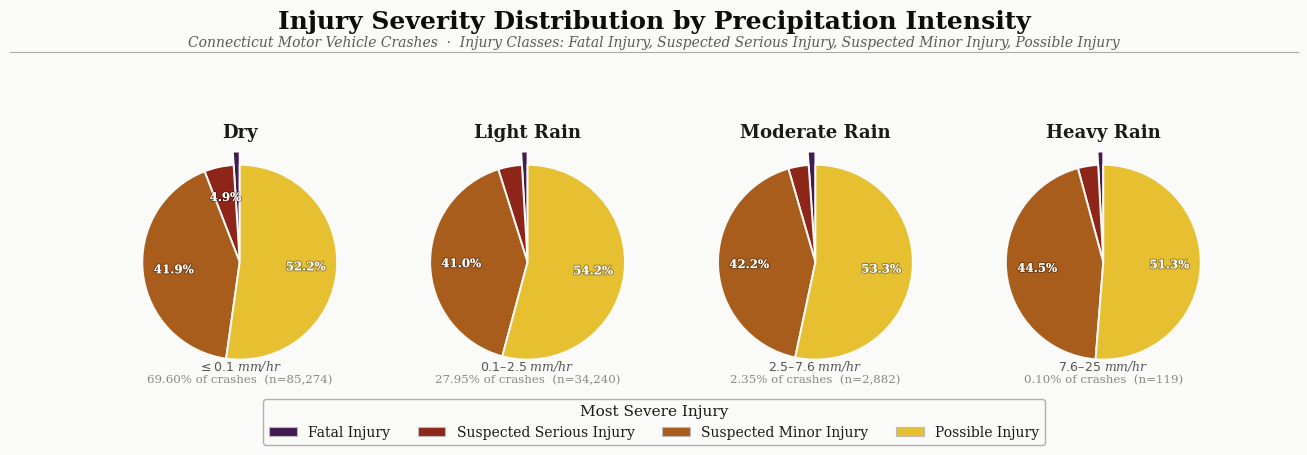

In [73]:
# ── Compute proportions from real data ───────────────────────────────────────
cats_present = [
    c for c in PRECIP_LABELS
    if c in crash_v['precip_cat'].cat.categories
    and crash_v['precip_cat'].value_counts().get(c, 0) > 0
]
n_cats = len(cats_present)

# Build per-category proportion table (A / B / C / K)
prop_table = (
    crash_v.groupby(['precip_cat', INJURY_COL], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['K', 'A', 'B', 'C'], fill_value=0)
)
prop_table_pct = prop_table.div(prop_table.sum(axis=1), axis=0)

# Share of all crashes per category
cat_share = crash_v['precip_cat'].value_counts(normalize=True).mul(100)

print('Injury proportions per precipitation category:')
print(prop_table)
print(prop_table_pct.round(3))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, n_cats,
    figsize=(3.5 * n_cats, 5.75),
    facecolor=BG,
)
if n_cats == 1:
    axes = [axes]

fig.suptitle(
    'Injury Severity Distribution by Precipitation Intensity',
    fontsize=18, fontweight='bold', color='#0D0D0D', y=0.97,
)
fig.text(
    0.5, 0.905,
    'Connecticut Motor Vehicle Crashes  ·  Injury Classes: Fatal Injury, Suspected Serious Injury, Suspected Minor Injury, Possible Injury',
    ha='center', fontsize=10, color="#5C5B5B", style='italic',
)
fig.add_artist(plt.Line2D([0.04, 0.96], [0.895, 0.895],
                          transform=fig.transFigure, color='#AAAAAA', lw=0.8))

pie_colors = [INJ_COLORS['K'], INJ_COLORS['A'], INJ_COLORS['B'], INJ_COLORS['C']]

for ax, cat in zip(axes, cats_present):
    ax.set_facecolor(PANEL_BG)
    vals = prop_table_pct.loc[cat, ['K', 'A', 'B', 'C']].values
    n_cat = prop_table.loc[cat].sum()
    share = cat_share.get(cat, 0.0)

    wedges, _, autotexts = ax.pie(
        vals,
        colors=pie_colors,
        autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
        pctdistance=0.68,
        startangle=90,
        wedgeprops={'linewidth': 1.4, 'edgecolor': BG},
        radius=1.1,
    )
    # Explode fatal wedge slightly
    wedges[0].set_radius(1.25)

    for at in autotexts:
        at.set_fontsize(8.5)
        at.set_color('white')
        at.set_fontweight('bold')
        at.set_path_effects([pe.withStroke(linewidth=1.5, foreground='#00000055')])

    # Category label
    idx = PRECIP_LABELS.index(cat)
    ax.set_title(cat, fontsize=13, fontweight='bold', color='#1A1A1A', pad=10)
    ax.text(0, -1.08, PRECIP_THRESH[idx],
            ha='center', va='top', fontsize=9, color='#555555', style='italic',
            transform=ax.transData)
    ax.text(0, -1.26, f'{share:.2f}% of crashes  (n={n_cat:,})',
            ha='center', va='top', fontsize=8.5, color='#888888',
            transform=ax.transData)
    ax.set_aspect('equal')

# Shared legend
legend_patches = [
    mpatches.Patch(facecolor=INJ_COLORS[k], edgecolor='#BBBBBB',
                   linewidth=0.8, label=INJ_LABELS[k])
    for k in ['K', 'A', 'B', 'C']
]
leg = fig.legend(
    handles=legend_patches, loc='lower center', ncol=4,
    bbox_to_anchor=(0.5, 0.2),
    frameon=True, framealpha=0.92,
    edgecolor='#AAAAAA', facecolor=BG,
    fontsize=10, title='Most Severe Injury', title_fontsize=11,
)
plt.subplots_adjust(bottom=0.18, wspace=0.3)
save_fig(fig, 'fig1_injury_by_precip')
plt.show()


---
## Figure 2 — Crash Count by Hour of Day and Precipitation Category

Saved → ../outputs/figures/fig2_crashes_by_hour_precip.[png|pdf]


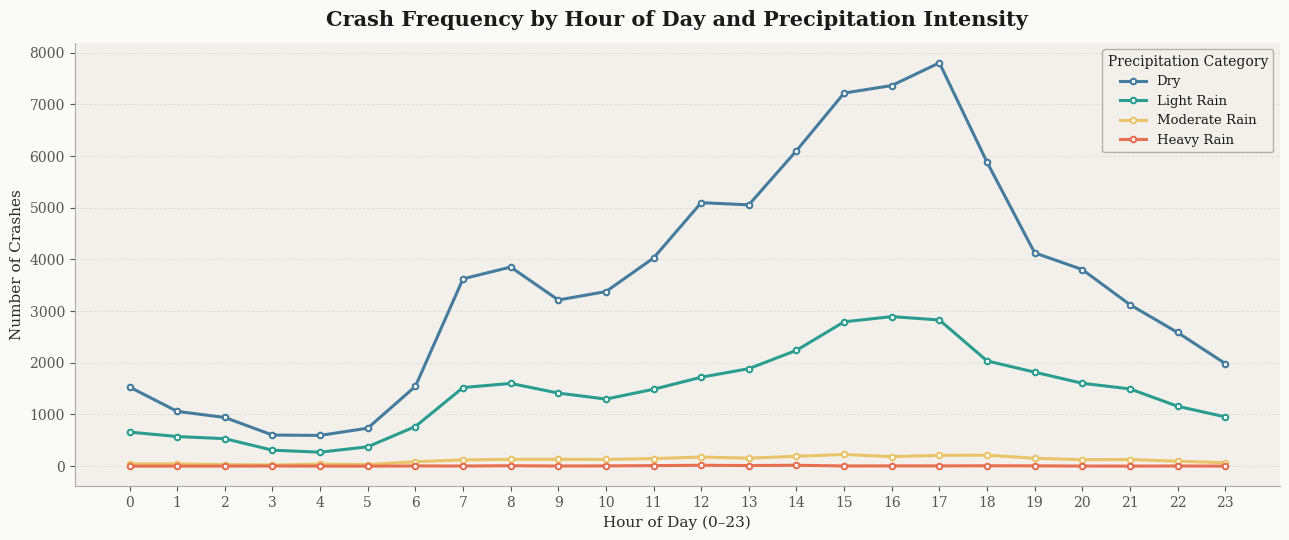

In [57]:
HOUR_COL = 'Hour of the Day'   # <-- update if needed

hourly = (
    crash_v.groupby([HOUR_COL, 'precip_cat'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=cats_present, fill_value=0)
)

HOUR_COLORS = ['#457B9D', '#2A9D8F', '#E9C46A', '#E76F51', '#6A0572']

fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=BG)
ax.set_facecolor(PANEL_BG)

for col, color in zip(cats_present, HOUR_COLORS):
    ax.plot(hourly.index, hourly[col], lw=2.2, color=color, label=col, marker='o',
            markersize=4, markerfacecolor='white', markeredgewidth=1.5)

ax.set_title('Crash Frequency by Hour of Day and Precipitation Intensity',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day (0–23)', fontsize=11)
ax.set_ylabel('Number of Crashes', fontsize=11)
ax.set_xticks(range(0, 24))
ax.grid(axis='y', linestyle='--')
ax.legend(title='Precipitation Category', fontsize=9.5, title_fontsize=10,
          framealpha=0.9, edgecolor='#AAAAAA')
plt.tight_layout()
save_fig(fig, 'fig2_crashes_by_hour_precip')
plt.show()

---
## Figure 3 — Injury Severity by Route Class

Saved → ../outputs/figures/fig3_injury_by_route_class.[png|pdf]


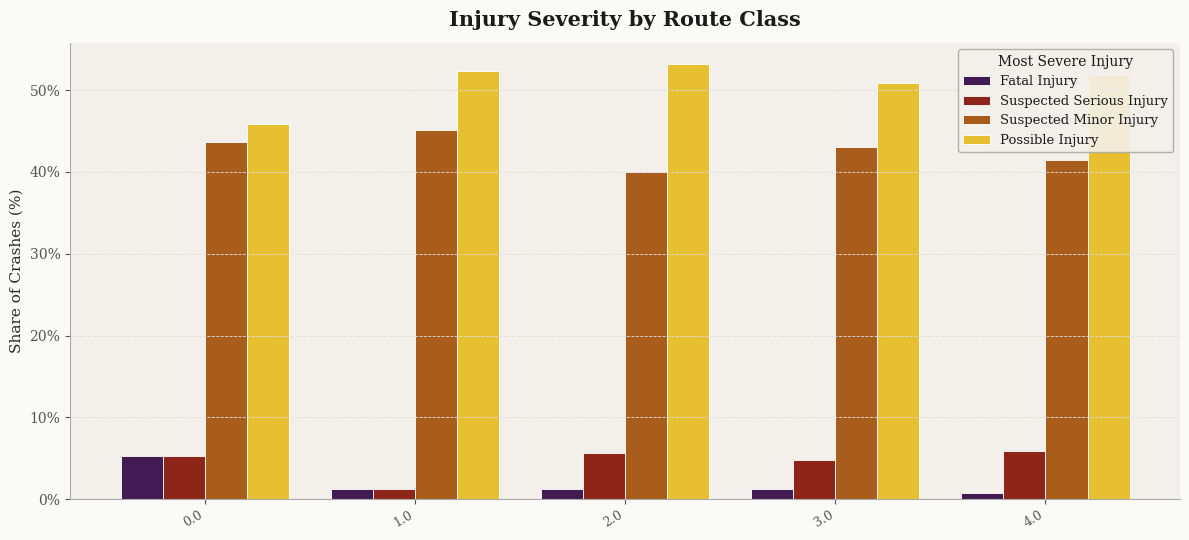

In [58]:
ROUTE_COL = 'Route Class'   # <-- update if needed

route_inj = (
    crash_v.groupby([ROUTE_COL, INJURY_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['K', 'A', 'B', 'C'], fill_value=0)
)
route_inj_pct = route_inj.div(route_inj.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor=BG)
ax.set_facecolor(PANEL_BG)

x = np.arange(len(route_inj_pct))
n_classes = 4
width = 0.20
offsets = [-1.5, -0.5, 0.5, 1.5]   # symmetric around each tick

for offset, (inj, label) in zip(offsets, INJ_LABELS.items()):
    bars = ax.bar(x + offset * width, route_inj_pct[inj], width,
                  color=INJ_COLORS[inj], label=label, edgecolor='white', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(route_inj_pct.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Share of Crashes (%)', fontsize=11)
ax.set_title('Injury Severity by Route Class', fontsize=15, fontweight='bold', pad=12)
ax.legend(title='Most Severe Injury', fontsize=9.5, title_fontsize=10,
          framealpha=0.9, edgecolor='#AAAAAA')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', linestyle='--')
plt.tight_layout()
save_fig(fig, 'fig3_injury_by_route_class')
plt.show()


---
## Figure 4 — Choropleth: Crash Rate per Road Mile by Town

Saved → ../outputs/figures/fig4_choropleth_crash_rate.[png|pdf]


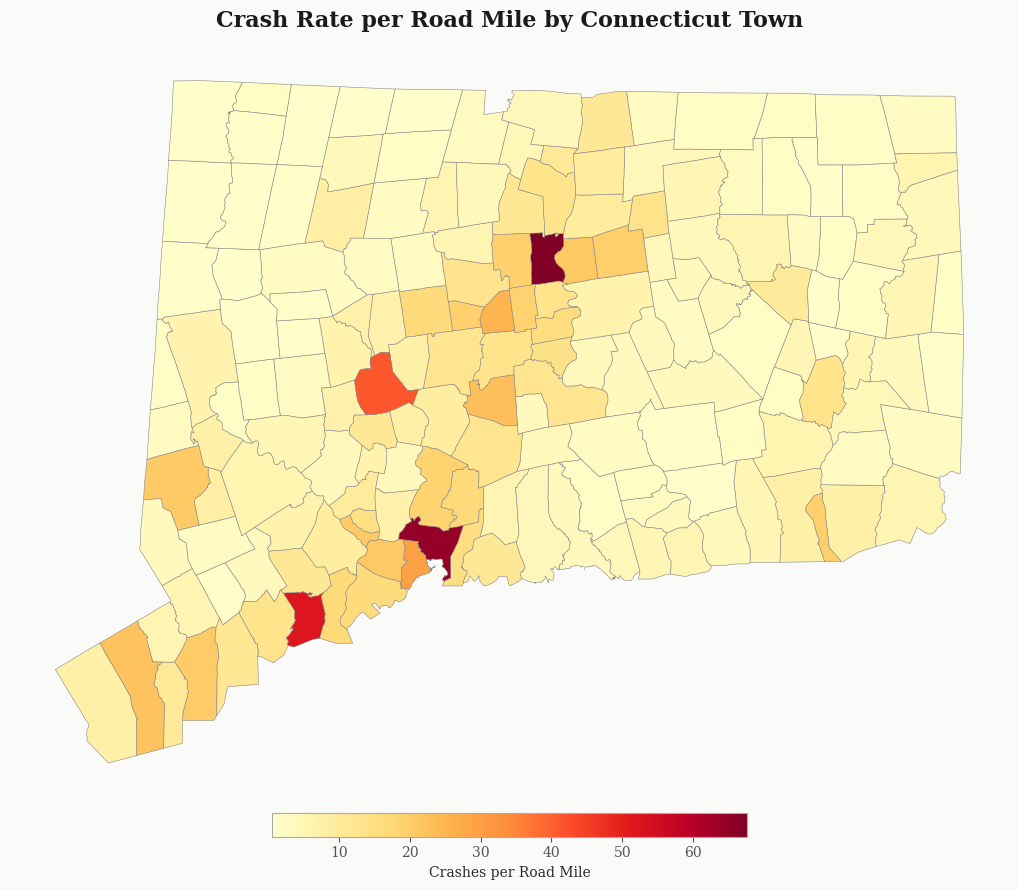

In [59]:
# Requires ct_towns_enhanced.gpkg and a town name column in crash data.
# Adjust TOWN_COL to match the town field in crash_data_weather.csv.
TOWN_COL = 'Town'   # <-- update if needed

crash_by_town = crash_v[TOWN_COL].value_counts().rename('crash_count').reset_index()
crash_by_town.columns = ['NAME20', 'crash_count']

towns_plot = ct_towns.merge(crash_by_town, on='NAME20', how='left')
towns_plot['crash_count'] = towns_plot['crash_count'].fillna(0)
towns_plot['crash_per_road_mi'] = towns_plot['crash_count'] / towns_plot['road_mi_total']

CT_CRS = 6433
towns_proj = towns_plot.to_crs(epsg=CT_CRS)

fig, ax = plt.subplots(1, 1, figsize=(14, 9), facecolor=BG)
ax.set_facecolor(BG)

towns_proj.plot(
    column='crash_per_road_mi',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#888888',
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': 'Crashes per Road Mile',
        'orientation': 'horizontal',
        'fraction': 0.03, 'pad': 0.02,
        'shrink': 0.6,
    },
    missing_kwds={'color': '#DDDDDD', 'label': 'No data'},
)

ax.set_title('Crash Rate per Road Mile by Connecticut Town',
             fontsize=16, fontweight='bold', pad=14)
ax.set_axis_off()
plt.tight_layout()
save_fig(fig, 'fig4_choropleth_crash_rate')
plt.show()

## Figure 4b - Regularizing by Road Miles and Population

Saved → ../outputs/figures/fig4c_multiplicative.[png|pdf]


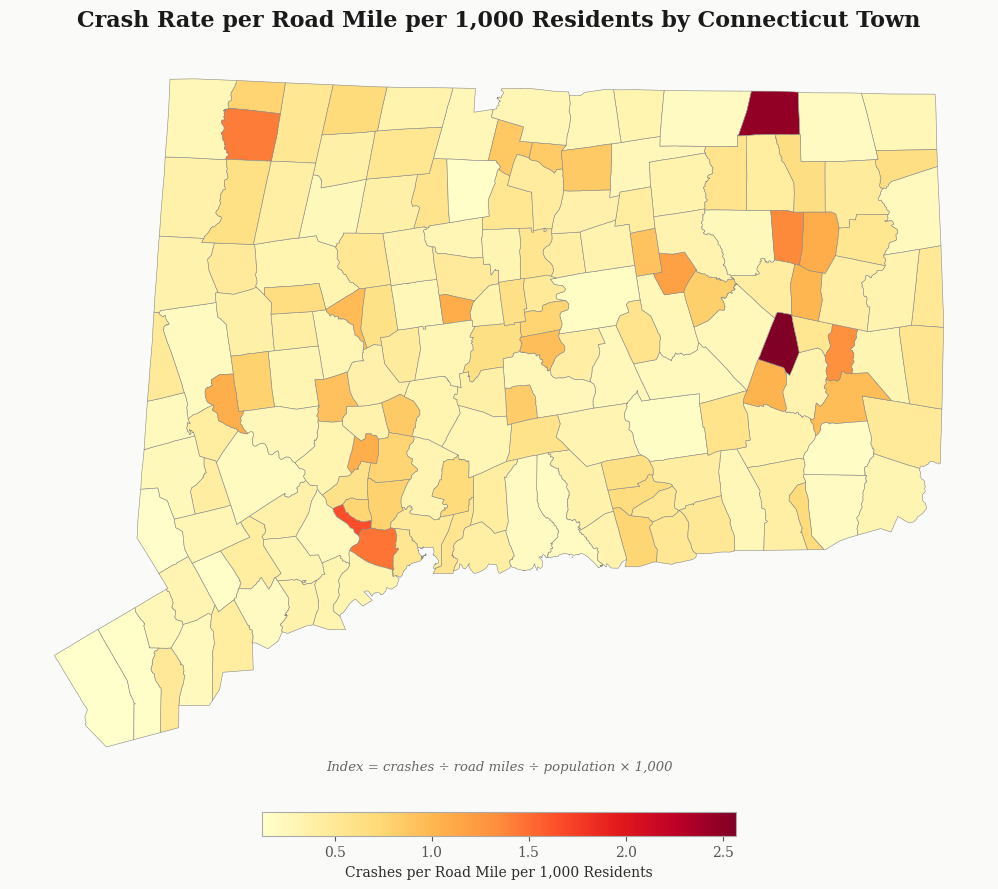

In [60]:
TOWN_COL = 'Town'

# ── Crash counts per town ─────────────────────────────────────────────────────
# (skip if towns_plot2 is already in memory from 4b above)
crash_by_town = crash_v[TOWN_COL].value_counts().rename('crash_count').reset_index()
crash_by_town.columns = ['NAME20', 'crash_count']

towns_plot3 = ct_towns.merge(crash_by_town, on='NAME20', how='left')
towns_plot3['crash_count'] = towns_plot3['crash_count'].fillna(0)

# Crashes per road-mile per 1,000 residents — straight multiplicative combination
# Units: (crashes / mile) / (persons / 1,000)  =  crashes·1000 / (mile·person)
towns_plot3['crash_per_mi_per_1k'] = (
    towns_plot3['crash_count']
    / towns_plot3['road_mi_total']
    / towns_plot3['DP05_0001E'].astype(float)
    * 1_000
)

CT_CRS = 6433
towns_proj3 = towns_plot3.to_crs(epsg=CT_CRS)

fig, ax = plt.subplots(1, 1, figsize=(14, 9), facecolor=BG)
ax.set_facecolor(BG)

towns_proj3.plot(
    column='crash_per_mi_per_1k',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#888888',
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': 'Crashes per Road Mile per 1,000 Residents',
        'orientation': 'horizontal',
        'fraction': 0.03, 'pad': 0.04,
        'shrink': 0.55,
    },
    missing_kwds={'color': '#DDDDDD', 'label': 'No data'},
)

ax.set_title('Crash Rate per Road Mile per 1,000 Residents by Connecticut Town',
             fontsize=16, fontweight='bold', pad=14)
ax.text(0.5, 0.01,
        'Index = crashes ÷ road miles ÷ population × 1,000',
        ha='center', va='bottom', fontsize=9.5, color='#666666', style='italic',
        transform=ax.transAxes)
ax.set_axis_off()
plt.tight_layout()
save_fig(fig, 'fig4c_multiplicative')
plt.show()

## Figure 4c - Regularizing by Road Miles and Population (Geometric Mean)

Saved → ../outputs/figures/fig4b_geomean.[png|pdf]


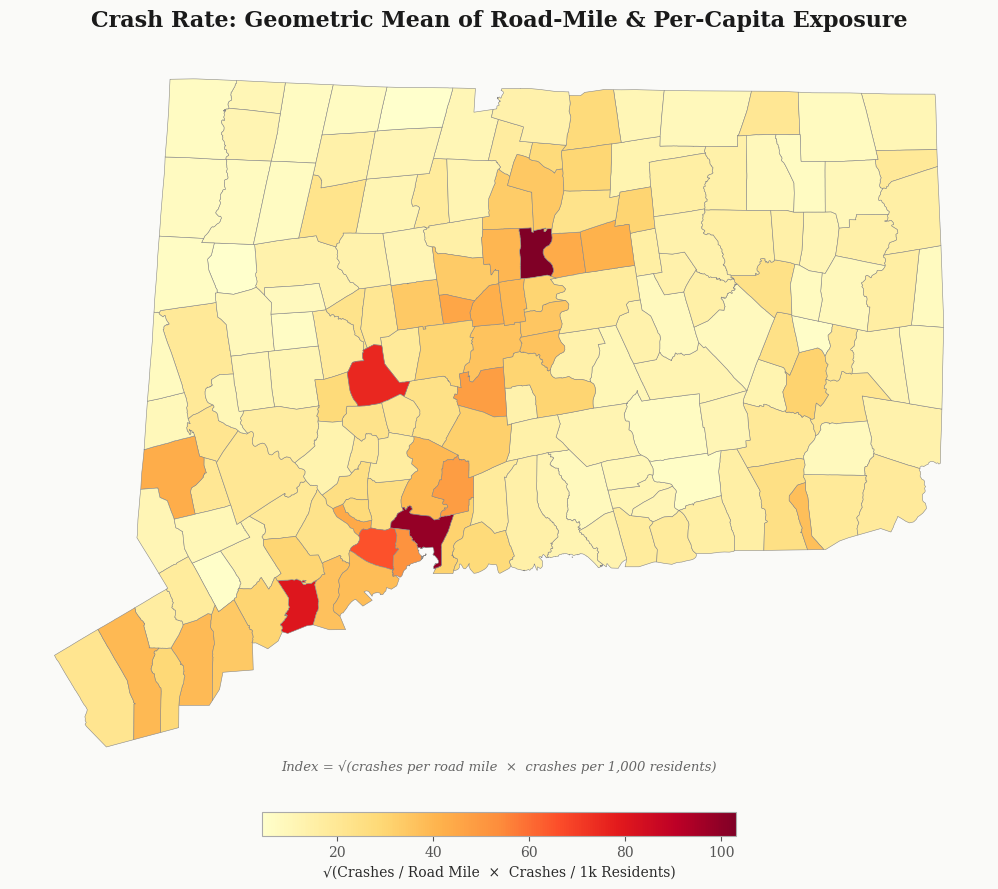

In [61]:
TOWN_COL = 'Town'

# ── Crash counts per town ─────────────────────────────────────────────────────
crash_by_town = crash_v[TOWN_COL].value_counts().rename('crash_count').reset_index()
crash_by_town.columns = ['NAME20', 'crash_count']

towns_plot2 = ct_towns.merge(crash_by_town, on='NAME20', how='left')
towns_plot2['crash_count'] = towns_plot2['crash_count'].fillna(0)

# Individual normalised rates
towns_plot2['crash_per_road_mi']  = towns_plot2['crash_count'] / towns_plot2['road_mi_total']
towns_plot2['crash_per_1k_pop']   = towns_plot2['crash_count'] / towns_plot2['DP05_0001E'].astype(float) * 1_000

# Geometric mean of the two rates
towns_plot2['crash_rate_geomean'] = np.sqrt(
    towns_plot2['crash_per_road_mi'] * towns_plot2['crash_per_1k_pop']
)

CT_CRS = 6433
towns_proj2 = towns_plot2.to_crs(epsg=CT_CRS)

fig, ax = plt.subplots(1, 1, figsize=(14, 9), facecolor=BG)
ax.set_facecolor(BG)

towns_proj2.plot(
    column='crash_rate_geomean',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#888888',
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': '√(Crashes / Road Mile  ×  Crashes / 1k Residents)',
        'orientation': 'horizontal',
        'fraction': 0.03, 'pad': 0.04,
        'shrink': 0.55,
    },
    missing_kwds={'color': '#DDDDDD', 'label': 'No data'},
)

ax.set_title('Crash Rate: Geometric Mean of Road-Mile & Per-Capita Exposure',
             fontsize=16, fontweight='bold', pad=14)
ax.text(0.5, 0.01,
        'Index = √(crashes per road mile  ×  crashes per 1,000 residents)',
        ha='center', va='bottom', fontsize=9.5, color='#666666', style='italic',
        transform=ax.transAxes)
ax.set_axis_off()
plt.tight_layout()
save_fig(fig, 'fig4b_geomean')
plt.show()

---
## Figure 5 — Wind Speed vs. Injury Severity (Box Plots)

Saved → ../outputs/figures/fig5_wind_by_injury.[png|pdf]


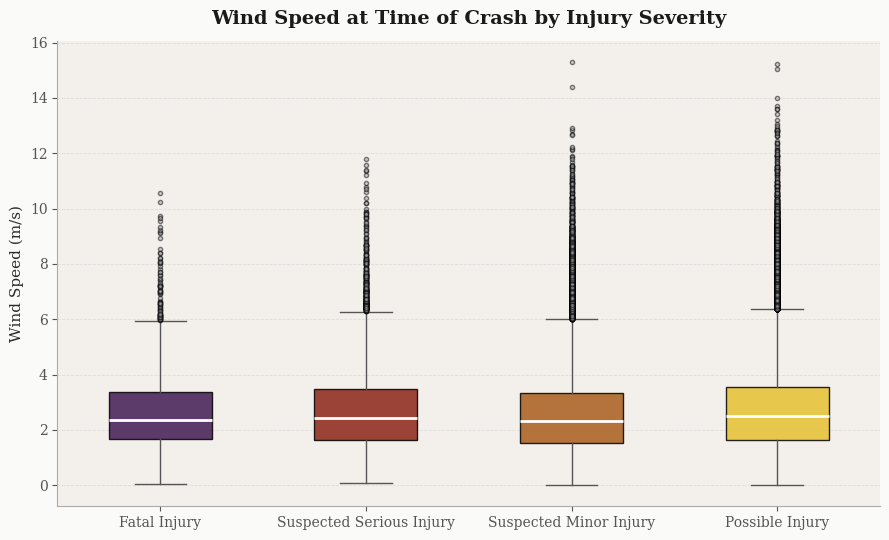

In [50]:
# Assumes 'wind_speed_ms' column exists (computed from u10/v10 in data_cleaning)
# Adjust column name as needed.
WIND_COL = 'wind_speed_ms'   # <-- update if needed

groups = [crash_v.loc[crash_v[INJURY_COL] == cls, WIND_COL].dropna()
          for cls in ['K', 'A', 'B', 'C']]

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=BG)
ax.set_facecolor(PANEL_BG)

bp = ax.boxplot(
    groups,
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
    whiskerprops={'color': '#555555'},
    capprops={'color': '#555555'},
    flierprops={'marker': 'o', 'markersize': 3,
                'markerfacecolor': '#AAAAAA', 'alpha': 0.5},
    widths=0.5,
)
for patch, cls in zip(bp['boxes'], ['K', 'A', 'B', 'C']):
    patch.set_facecolor(INJ_COLORS[cls])
    patch.set_alpha(0.85)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([INJ_LABELS[c] for c in ['K', 'A', 'B', 'C']], fontsize=10)
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Wind Speed at Time of Crash by Injury Severity',
             fontsize=14, fontweight='bold', pad=12)
ax.grid(axis='y', linestyle='--')
plt.tight_layout()
save_fig(fig, 'fig5_wind_by_injury')
plt.show()


---
## Figure 6 — Crash Count Heatmap: Day of Week × Hour of Day

Saved → ../outputs/figures/fig6_heatmap_dow_hour.[png|pdf]


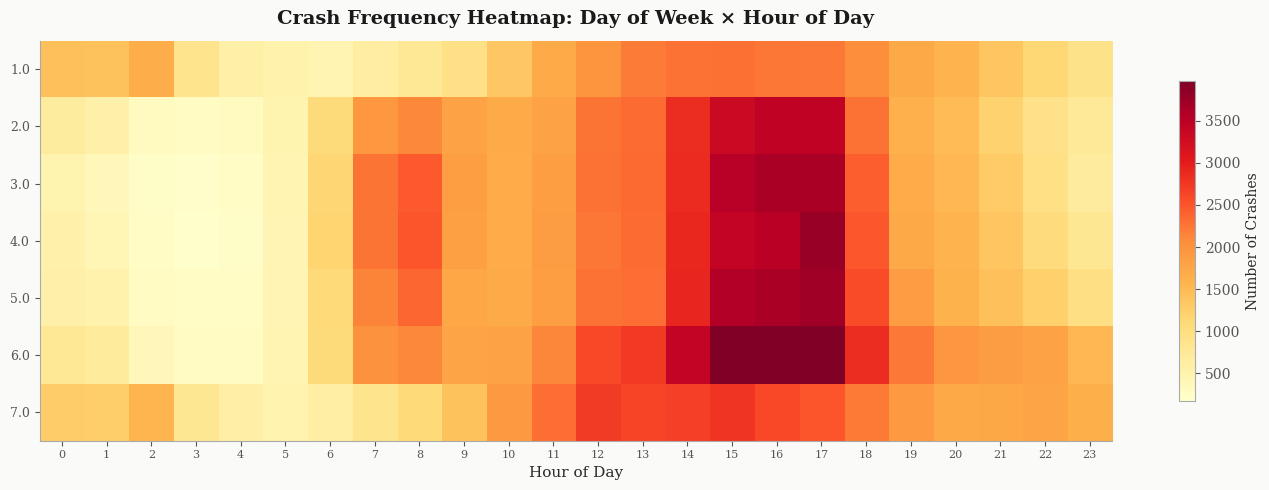

In [51]:
DOW_COL = 'Day of the Week'   # <-- update if needed

# Normalise day labels if numeric (0=Mon or 0=Sun depending on source)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    crash_v.groupby([DOW_COL, HOUR_COL])
    .size()
    .unstack(fill_value=0)
)
# Reindex rows to canonical day order if string labels match
existing_days = [d for d in day_order if d in heatmap_data.index]
if existing_days:
    heatmap_data = heatmap_data.reindex(existing_days)

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)

im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd',
               interpolation='nearest')
plt.colorbar(im, ax=ax, label='Number of Crashes', shrink=0.8)

ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_title('Crash Frequency Heatmap: Day of Week × Hour of Day',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
save_fig(fig, 'fig6_heatmap_dow_hour')
plt.show()

In [62]:
import os, glob
from PIL import Image
from tqdm import tqdm

FRAME_DIR = "../../animation_output/frames"
GIF_PATH  = "../../animation_output/ct_storm_animation.gif"
FPS       = 8

frame_files = sorted(glob.glob(os.path.join(FRAME_DIR, "frame_*.png")))
with Image.open(frame_files[0]) as ref:
    size = ref.size

frames = []
for fp in tqdm(frame_files, desc="Loading"):
    img = Image.open(fp).convert("RGB")
    if img.size != size:
        img = img.resize(size, Image.LANCZOS)
    frames.append(img)

frames[0].save(
    GIF_PATH, save_all=True, append_images=frames[1:],
    duration=int(1000 / FPS), loop=0, optimize=False
)
print(f"✓ Saved → {GIF_PATH}")

Loading: 100%|██████████| 486/486 [00:15<00:00, 31.01it/s]


✓ Saved → ../../animation_output/ct_storm_animation.gif


In [67]:
import os, glob
from PIL import Image
from tqdm import tqdm

FRAME_DIR = "../../animation_output/frames"
GIF_PATH  = "../../animation_output/ct_storm_animation_cropped.gif"
FPS       = 8

# Crop: remove top 70px (title) and right side beyond 1360px (colorbar)
# Original: 1556w x 1133h  →  target: 1360w x 1063h
CROP_BOX = (80, 58, 1490, 1133)   # (left, top, right, bottom)

frame_files = sorted(glob.glob(os.path.join(FRAME_DIR, "frame_*.png")))
print(f"Found {len(frame_files)} frames — cropping to {CROP_BOX[2]}x{CROP_BOX[3] - CROP_BOX[1]} px")

frames = []
for fp in tqdm(frame_files, desc="Cropping"):
    img = Image.open(fp).convert("RGB").crop(CROP_BOX)
    frames.append(img)

print(f"Saving GIF → {GIF_PATH}")
frames[0].save(
    GIF_PATH, save_all=True, append_images=frames[1:],
    duration=int(1000 / FPS), loop=0, optimize=False
)
print("✓ Done!")

Found 486 frames — cropping to 1490x1075 px


Cropping: 100%|██████████| 486/486 [00:16<00:00, 30.09it/s]


Saving GIF → ../../animation_output/ct_storm_animation_cropped.gif
✓ Done!


In [68]:
import os, glob
from PIL import Image
from tqdm import tqdm

FRAME_DIR  = "../../animation_output/frames"
GIF_IN     = "../../animation_output/ct_storm_animation_cropped.gif"   # existing cropped GIF
GIF_OUT    = "../../animation_output/ct_storm_animation_compressed.gif"
FPS        = 6

# ── Compression levers ────────────────────────────────────────────────────────
# 1. Colour palette: GIF max is 256 colours.  Fewer → smaller file.
#    192–256 = near-lossless; 128 = good quality; 64 = noticeable but small.
N_COLORS = 128

# 2. Scale factor: 1.0 = original size, 0.75 = 75% width+height (56% of pixels).
#    0.85 is barely perceptible on screen; 0.75 saves a lot.
SCALE = 0.85

# 3. Dithering: helps smooth colour banding from palette reduction.
#    Image.Dither.FLOYDSTEINBERG (default) or Image.Dither.NONE (sharper, smaller)
DITHER = Image.Dither.FLOYDSTEINBERG
# ─────────────────────────────────────────────────────────────────────────────

CROP_BOX = (0, 70, 1360, 1133)   # same crop as before — skip if already cropped

# Load from existing cropped GIF if available, otherwise re-crop from frames
if os.path.exists(GIF_IN):
    print(f"Loading from {GIF_IN} …")
    src = Image.open(GIF_IN)
    frames_raw = []
    try:
        while True:
            frames_raw.append(src.copy().convert("RGB"))
            src.seek(src.tell() + 1)
    except EOFError:
        pass
    print(f"  {len(frames_raw)} frames loaded from GIF")
else:
    print(f"GIF not found — loading from frames in {FRAME_DIR} …")
    frame_files = sorted(glob.glob(os.path.join(FRAME_DIR, "frame_*.png")))
    frames_raw = [Image.open(fp).convert("RGB").crop(CROP_BOX) for fp in tqdm(frame_files)]

# ── Compute target size ───────────────────────────────────────────────────────
orig_w, orig_h = frames_raw[0].size
new_w = int(orig_w * SCALE / 2) * 2   # keep even
new_h = int(orig_h * SCALE / 2) * 2
print(f"Original size : {orig_w}×{orig_h}")
print(f"Output size   : {new_w}×{new_h}  (scale={SCALE})")
print(f"Palette       : {N_COLORS} colours")

# ── Process frames ────────────────────────────────────────────────────────────
frames_out = []
for img in tqdm(frames_raw, desc="Quantizing"):
    if SCALE != 1.0:
        img = img.resize((new_w, new_h), Image.LANCZOS)
    # Quantize to N_COLORS palette with dithering
    img = img.quantize(colors=N_COLORS, method=Image.Quantize.MEDIANCUT,
                       dither=DITHER)
    frames_out.append(img)

# ── Save ──────────────────────────────────────────────────────────────────────
print(f"Saving → {GIF_OUT} …")
frames_out[0].save(
    GIF_OUT,
    save_all=True,
    append_images=frames_out[1:],
    duration=int(1000 / FPS),
    loop=0,
    optimize=True,        # LZW compression pass
)

orig_mb = os.path.getsize(GIF_IN) / 1e6 if os.path.exists(GIF_IN) else None
out_mb  = os.path.getsize(GIF_OUT) / 1e6
print(f"✓ Done!")
if orig_mb:
    print(f"  {orig_mb:.1f} MB  →  {out_mb:.1f} MB  ({100*(1-out_mb/orig_mb):.0f}% reduction)")
else:
    print(f"  Output size: {out_mb:.1f} MB")

Loading from ../../animation_output/ct_storm_animation_cropped.gif …
  481 frames loaded from GIF
Original size : 1410×1075
Output size   : 1198×912  (scale=0.85)
Palette       : 128 colours


Quantizing: 100%|██████████| 481/481 [00:43<00:00, 11.09it/s]


Saving → ../../animation_output/ct_storm_animation_compressed.gif …
✓ Done!
  Output size: 84.2 MB


# Querying Data for Proposal Stats

# Find Proportion, Count of data in precipitation categories

# Find Injury categories by Proportion, Count in data